# ASR error rates on SLURP

Take a fixed number of **news** and **ecommerce** clips from the SLURP test set, transcribe each clip with the project ASR models, and report word error rate (WER) and character error rate (CER).

In [1]:
import io
import os
import jiwer
import numpy as np
import pandas as pd
import soundfile as sf
from datasets import Audio, load_dataset
from dotenv import load_dotenv
from src.utils.models import ASR_MODELS, Models

load_dotenv()

/home/rakesh/Downloads/ShortTok/2.NoiseCancellation/NoiseCancellation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
DATASET = "qmeeus/slurp"
SLURP_CSV = "audio/open_source/slurp.csv"
INTENTS = {
    "news": {"news_query"},
    "ecommerce": {"lists_createoradd", "lists_query", "lists_remove", "takeaway_order", "takeaway_query"},
}

In [3]:
def intent_name(labels, intent):
    return labels.int2str(intent) if isinstance(intent, int) else intent


def decode_audio(audio):
    samples, sampling_rate = sf.read(io.BytesIO(audio["bytes"]), dtype="float32")
    samples = np.asarray(samples, np.float32)
    if samples.ndim > 1:
        samples = samples.mean(axis=1)
    return sampling_rate, samples

In [4]:
def load_samples(per_group=50, split="test"):
    if os.path.exists(SLURP_CSV):
        rows = pd.read_csv(SLURP_CSV)
        samples = []
        for row in rows.itertuples(index=False):
            array, sampling_rate = sf.read(row.audio, dtype="float32")
            samples.append({"group": row.group, "intent": row.intent, "text": row.text, "audio": (sampling_rate, np.asarray(array, np.float32))})
        print({group: int((rows.group == group).sum()) for group in INTENTS}, "total", len(samples))
        return samples

    wanted = {name: group for group, names in INTENTS.items() for name in names}
    buckets = {group: [] for group in INTENTS}
    stream = load_dataset(DATASET, split=split, streaming=True)
    labels = stream.features["intent"]
    stream = stream.cast_column("audio", Audio(decode=False))

    for row in stream:
        name = intent_name(labels, row["intent"])
        group = wanted.get(name)
        if group is None or len(buckets[group]) >= per_group:
            continue
        buckets[group].append({
            "group": group,
            "intent": name,
            "text": row["sentence"],
            "audio": decode_audio(row["audio"]),
        })
        if all(len(items) == per_group for items in buckets.values()):
            break

    samples = [item for items in buckets.values() for item in items]
    os.makedirs(os.path.dirname(SLURP_CSV), exist_ok=True)
    records = []
    for sample in samples:
        sampling_rate, array = sample["audio"]
        safe = " ".join(sample["text"].replace("/", " ").split()).rstrip(".")[:120].rstrip() or "audio"
        path, count = f"{os.path.dirname(SLURP_CSV)}/{safe}.wav", 2
        while os.path.exists(path):
            path, count = f"{os.path.dirname(SLURP_CSV)}/{safe} {count}.wav", count + 1
        sf.write(path, array, sampling_rate)
        records.append({"group": sample["group"], "intent": sample["intent"], "text": sample["text"], "audio": path})
    pd.DataFrame(records).to_csv(SLURP_CSV, index=False)
    print({group: len(items) for group, items in buckets.items()}, "total", len(samples))
    return samples

In [5]:
samples = load_samples(per_group=50)
samples[:2]

{'news': 50, 'ecommerce': 50} total 100


[{'group': 'news',
  'intent': 'news_query',
  'text': 'what is the exchange rate of us dollar to pound sterling',
  'audio': (16000,
   array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00, -3.0517578e-05,  0.0000000e+00], dtype=float32))},
 {'group': 'news',
  'intent': 'news_query',
  'text': 'what is the exchange rate of us dollar to pound sterling',
  'audio': (16000,
   array([ 0.0000000e+00, -6.1035156e-05,  6.1035156e-05, ...,
           9.2773438e-02,  1.2808228e-01,  3.0517578e-05], dtype=float32))}]

In [6]:
from whisper.normalizers import EnglishTextNormalizer

normalize = EnglishTextNormalizer()

def score(samples, hypotheses, group):
    chosen = [
        (normalize(sample["text"]), normalize(hypothesis))
        for sample, hypothesis in zip(samples, hypotheses)
        if group == "all" or sample["group"] == group
    ]
    references, group_hypotheses = zip(*chosen)
    return jiwer.wer(list(references), list(group_hypotheses)), jiwer.cer(list(references), list(group_hypotheses)), len(chosen)

In [7]:
import asyncio
import json
import time

import requests

GROUPS = [
    "slurp_news", "slurp_ecommerce",
    "recorded_clean_news", "recorded_clean_ecommerce",
    "recorded_noisy_news", "recorded_noisy_ecommerce",
]

from tqdm.auto import tqdm

def transcribe_samples(models, samples):
    transcriptions = {}
    for name, asr in zip(models.names, models.asrs):
        hypotheses, elapsed = [], []
        for sample in tqdm(samples, desc=name):
            start = time.perf_counter()
            hypotheses.append(models.transcribe(sample["audio"], asr))
            elapsed.append((time.perf_counter() - start) * 1000)
        transcriptions[name] = (hypotheses, elapsed)
    return transcriptions


def wav_bytes(audio):
    sampling_rate, samples = audio
    buffer = io.BytesIO()
    sf.write(buffer, np.asarray(samples, np.float32), int(sampling_rate), format="WAV")
    return buffer.getvalue()


API_LIMIT = {"deepgram": 4, "elevenlabs": 4, "assemblyai": 4, "speechmatics": 2}

async def _transcribe_api(samples, call, name):
    limit = asyncio.Semaphore(API_LIMIT.get(name, 1))
    results = [None] * len(samples)
    progress = tqdm(total=len(samples), desc=name)

    async def one(index, sample):
        async with limit:
            start = time.perf_counter()
            text = await asyncio.to_thread(call, wav_bytes(sample["audio"]))
            results[index] = (text, (time.perf_counter() - start) * 1000)
            progress.update(1)

    await asyncio.gather(*(one(index, sample) for index, sample in enumerate(samples)))
    progress.close()
    hypotheses, elapsed = zip(*results)
    return list(hypotheses), list(elapsed)

def transcribe_api(samples, call, name):
    task = _transcribe_api(samples, call, name)
    try:
        asyncio.get_running_loop()
    except RuntimeError:
        return asyncio.run(task)
    from concurrent.futures import ThreadPoolExecutor
    with ThreadPoolExecutor(1) as pool:
        return pool.submit(asyncio.run, task).result()


def deepgram(wav):
    response = requests.post(
        "https://api.deepgram.com/v1/listen",
        params={"model": "nova-3", "language": "en"},
        headers={"Authorization": f"Token {os.environ['DEEPGRAM_API_KEY']}", "Content-Type": "audio/wav"},
        data=wav,
        timeout=60,
    )
    response.raise_for_status()
    return response.json()["results"]["channels"][0]["alternatives"][0]["transcript"]


def elevenlabs(wav):
    response = requests.post(
        "https://api.elevenlabs.io/v1/speech-to-text",
        headers={"xi-api-key": os.environ["ELEVENLABS_API_KEY"]},
        files={"file": ("clip.wav", wav, "audio/wav")},
        data={"model_id": "scribe_v2", "language_code": "en"},
        timeout=60,
    )
    response.raise_for_status()
    return response.json().get("text") or ""


def assemblyai(wav):
    response = requests.post(
        "https://sync.assemblyai.com/v1/transcribe",
        headers={"Authorization": os.environ["ASSEMBLYAI_API_KEY"], "X-AAI-Model": "universal-3-5-pro"},
        files={"audio": ("clip.wav", wav, "audio/wav")},
        timeout=60,
    )
    response.raise_for_status()
    return response.json().get("text") or ""


def speechmatics(wav):
    response = requests.post(
        os.environ.get("SPEECHMATICS_URL", "https://eu1.asr.api.speechmatics.com/v2/jobs"),
        params={"wait": 60, "format": "txt"},
        headers={"Authorization": f"Bearer {os.environ['SPEECHMATICS_API_KEY']}"},
        files={"data_file": ("clip.wav", wav, "audio/wav")},
        data={"config": json.dumps({"type": "transcription", "transcription_config": {"language": "en", "model": "enhanced"}})},
        timeout=90,
    )
    response.raise_for_status()
    body = response.json()
    if body.get("status") != "done":
        raise RuntimeError(body.get("status"))
    return body.get("txt") or ""


def evaluate(samples, transcriptions):
    rows = []
    for name, (hypotheses, elapsed) in transcriptions.items():
        for group in GROUPS:
            wer, cer, count = score(samples, hypotheses, group)
            indexes = [i for i, sample in enumerate(samples) if sample["group"] == group]
            latency = sum(elapsed[i] for i in indexes) / count
            rows.append({"model": name, "group": group, "wer": f"{wer * 100:.1f}%", "cer": f"{cer * 100:.1f}%", "latency": f"{round(latency)} ms"})
    return pd.DataFrame(rows)

In [8]:
import gc
import torch

NOISES = ("Claps & Cheers", "Traffic & Wind", "Retail Ambient Noise")

def load_recorded(kind):
    directory = f"audio/recorded/{kind}"
    loaded = []
    for name in sorted(os.listdir(directory)):
        if not name.endswith(".wav"):
            continue
        text = os.path.splitext(name)[0]
        for noise in NOISES:
            marker = f"_{noise}_"
            if marker in text:
                text = text.split(marker)[0]
                break
        lowered = text.lower()
        topic = "news" if "news" in lowered or "washington" in lowered or lowered.startswith("what's up") else "ecommerce"
        array, sampling_rate = sf.read(f"{directory}/{name}", dtype="float32")
        if array.ndim > 1:
            array = array.mean(axis=1)
        loaded.append({"group": f"recorded_{kind}_{topic}", "text": text, "audio": (sampling_rate, np.asarray(array, np.float32))})
    return loaded

all_samples = [{**sample, "group": f"slurp_{sample['group']}"} for sample in samples]
all_samples += load_recorded("clean") + load_recorded("noisy")
print({group: sum(sample["group"] == group for sample in all_samples) for group in GROUPS})

os.makedirs("results", exist_ok=True)
frames, predictions = [], []

def keep(transcriptions):
    for name, (hypotheses, elapsed) in transcriptions.items():
        for index, (sample, hypothesis, ms) in enumerate(zip(all_samples, hypotheses, elapsed)):
            predictions.append({"model": name, "index": index, "group": sample["group"], "text": sample["text"], "prediction": hypothesis, "latency_ms": round(ms, 1)})
    frames.append(evaluate(all_samples, transcriptions))

asr_models = None
for name in ASR_MODELS:
    if asr_models is not None:
        del asr_models
        gc.collect()
        torch.cuda.empty_cache()
    asr_models = Models(name)
    keep(transcribe_samples(asr_models, all_samples))
load_dotenv(override=True)
API_MODELS = {"deepgram": deepgram, "elevenlabs": elevenlabs, "assemblyai": assemblyai, "speechmatics": speechmatics}
missing = [key for key in ("DEEPGRAM_API_KEY", "ELEVENLABS_API_KEY", "ASSEMBLYAI_API_KEY", "SPEECHMATICS_API_KEY") if not os.environ.get(key)]
if missing:
    raise RuntimeError(f"Set {', '.join(missing)} in .env")
for name, call in API_MODELS.items():
    keep({name: transcribe_api(all_samples, call, name)})
metrics = pd.concat(frames, ignore_index=True)
pd.DataFrame(predictions).to_csv("results/predictions.csv", index=False)
metrics.to_csv("results/metrics.csv", index=False)
metrics

{'slurp_news': 50, 'slurp_ecommerce': 50, 'recorded_clean_news': 9, 'recorded_clean_ecommerce': 6, 'recorded_noisy_news': 108, 'recorded_noisy_ecommerce': 72}


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 4289.60it/s]


asr_freq: whisper-small 16000


whisper-small:   0%|          | 0/295 [00:00<?, ?it/s][transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Passing `generation_config` together with generation-related arguments=({'begin_suppress_tokens', 'suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
Loading weights: 100%|██████████| 1259/1259 [00:00<00:00, 3705.81it/s]


asr_freq: whisper-large 16000


Loading weights: 100%|██████████| 723/723 [00:00<00:00, 3794.82it/s]


asr_freq: parakeet 16000


parakeet:   0%|          | 0/295 [00:00<?, ?it/s]/home/rakesh/Downloads/ShortTok/2.NoiseCancellation/NoiseCancellation/.venv/lib/python3.12/site-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=490) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
parakeet:   3%|▎         | 8/295 [00:01<00:47,  6.00it/s]/home/rakesh/Downloads/ShortTok/2.NoiseCancellation/NoiseCancellation/.venv/lib/python3.12/site-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=580) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
parakeet:   5%|▌         | 16/295 [00:01<00:22, 12.28it/s]/home/rakesh/Downloads/ShortTok/2.NoiseCancellation/NoiseCancellation/.venv/lib/python3.12/site-packages/transformers/generation/utils.py:16

,model,group,wer,cer,latency
0,whisper-small,slurp_news,22.2%,12.9%,91 ms
1,whisper-small,slurp_ecommerce,26.6%,13.7%,53 ms
2,whisper-small,recorded_clean_news,0.0%,0.0%,57 ms
3,whisper-small,recorded_clean_ecommerce,11.9%,6.8%,57 ms
4,whisper-small,recorded_noisy_news,19.4%,11.5%,58 ms
5,whisper-small,recorded_noisy_ecommerce,24.0%,14.0%,58 ms
6,whisper-large,slurp_news,10.2%,6.6%,609 ms
7,whisper-large,slurp_ecommerce,12.7%,6.9%,549 ms
8,whisper-large,recorded_clean_news,0.0%,0.0%,620 ms
9,whisper-large,recorded_clean_ecommerce,0.0%,0.0%,615 ms


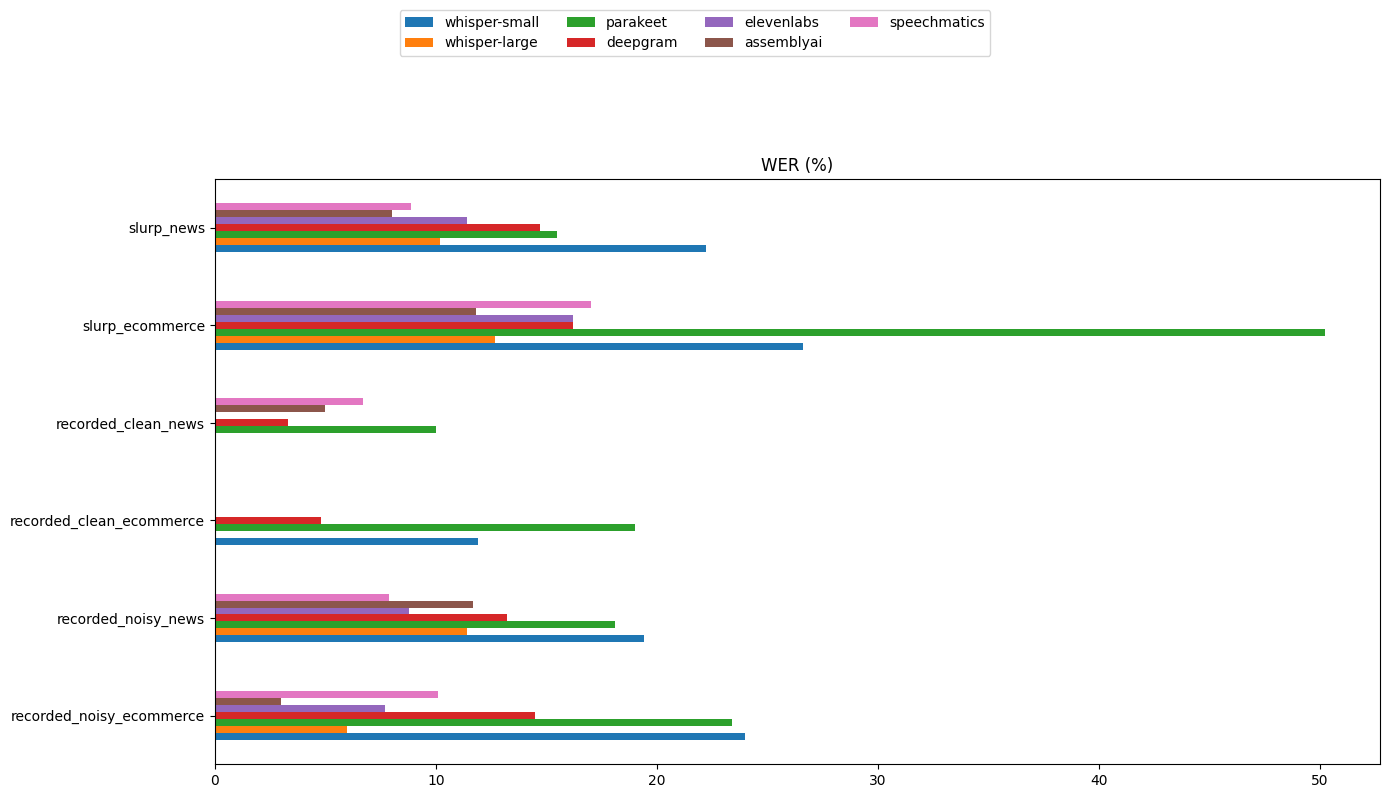

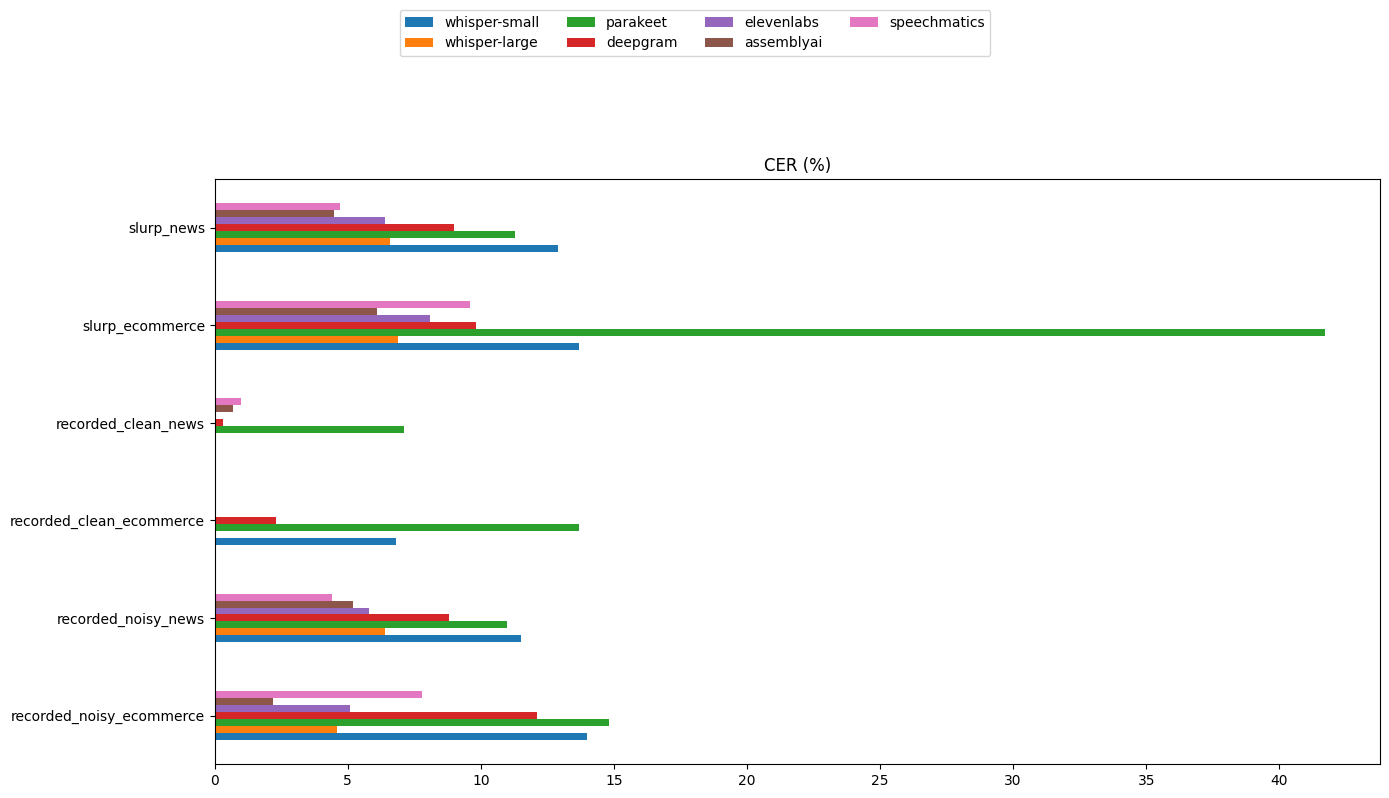

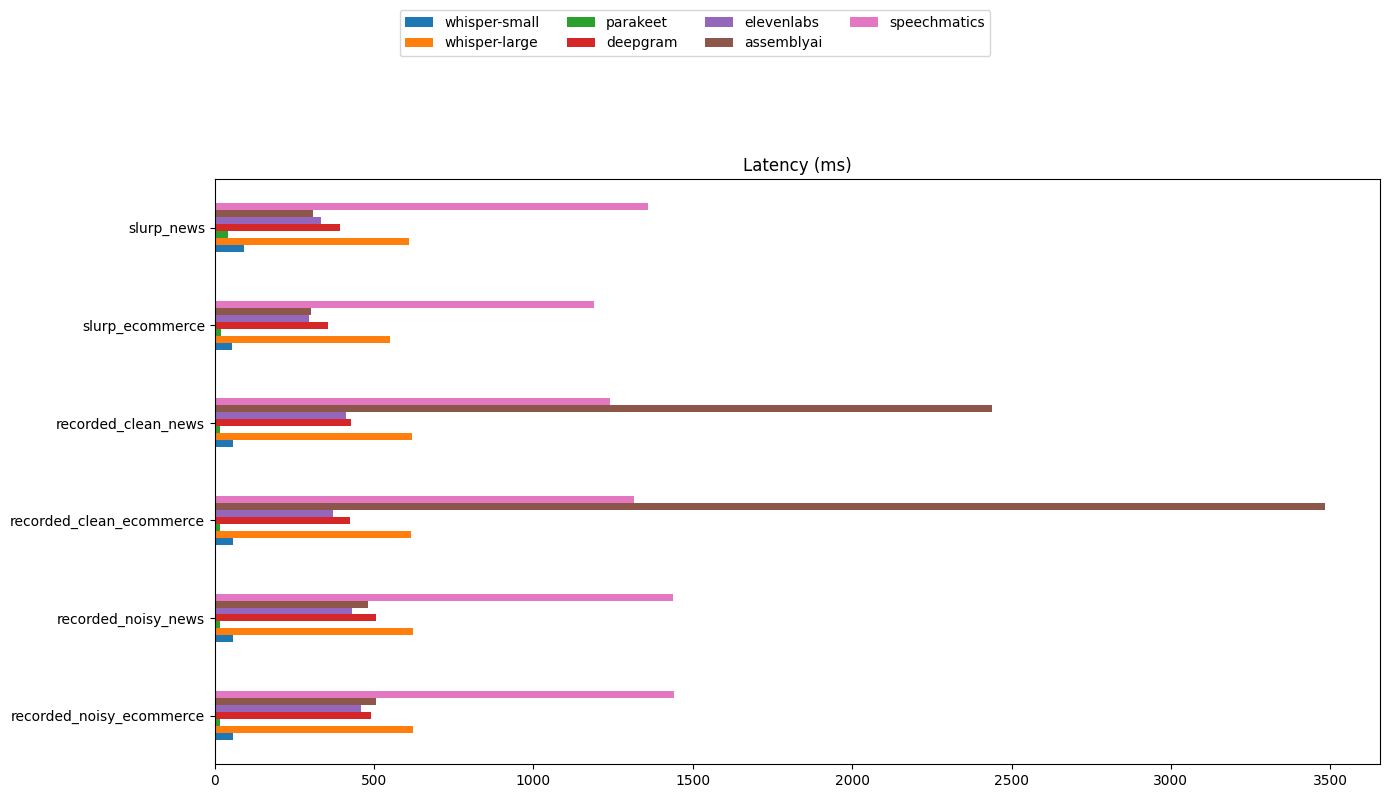

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

numbers = metrics.assign(
    wer=metrics["wer"].str.removesuffix("%").astype(float),
    cer=metrics["cer"].str.removesuffix("%").astype(float),
    latency=metrics["latency"].str.removesuffix(" ms").astype(float),
)
models = ["whisper-small", "whisper-large", "parakeet", "deepgram", "elevenlabs", "assemblyai", "speechmatics"]
models = [name for name in models if name in set(numbers["model"])]
for column, title in zip(["wer", "cer", "latency"], ["WER (%)", "CER (%)", "Latency (ms)"]):
    ax = numbers.pivot(index="group", columns="model", values=column).reindex(GROUPS[::-1])[models].plot.barh(figsize=(14, 8), legend=False)
    ax.set_title(title)
    ax.set_ylabel("")
    handles, labels = ax.get_legend_handles_labels()
    ax.figure.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.0))
    ax.figure.tight_layout()
    ax.figure.subplots_adjust(top=0.78)
    ax.figure.savefig(f"results/{column}.png", bbox_inches="tight")
plt.show()